In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [3]:
df=pd.read_csv("/content/online.CSV")
df

,Unnamed: 0,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications,Unnamed: 13,9,#@%
0,0,Yes,25001 to 50000,13.0262,Married,Male,Employee,5.0,Positive,560045,28.0,77.6200,Post Graduate,Yes,NaN,swiggyscount
1,1,Yes,No Income,12.9770,Single,Male,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate,Yes,NaN,*7435
2,2,Yes,No Income,12.9770,Single,Female,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate,Yes,NaN,*7435
3,3,Yes,No Income,13.0019,Single,Female,Student,NaN,Positive,560003,NaN,77.5713,Post Graduate,Yes,NaN,*7435
4,4,Yes,More than 50000,13.0626,Married,Male,Self Employeed,NaN,Positive,560015,NaN,77.5284,School,Yes,NaN,*7435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,383,Yes,No Income,12.9883,Single,Female,Student,5.0,Positive,560051,24.0,77.5987,Post Graduate,Yes,NaN,NaN
384,384,Yes,No Income,13.0223,Single,Male,Student,3.0,Positive,560049,23.0,77.7132,Graduate,Yes,NaN,NaN
385,385,Yes,10001 to 25000,12.9850,Single,Female,Student,5.0,Positive,560010,22.0,77.5533,Post Graduate,Yes,NaN,NaN
386,386,Yes,10001 to 25000,12.9698,Single,Female,Employee,3.0,Positive,560066,22.0,77.7500,Graduate,Yes,NaN,NaN


In [5]:
df.shape

(388, 16)

In [6]:
df.columns

Index(['Unnamed: 0', 'order_status', 'Monthly Income', 'latitude',
       'Marital Status', 'Gender', 'employment_status', 'Family size',
       'Reviews', 'Pin code', 'Age', 'longitude', 'Educational Qualifications',
       'Unnamed: 13', '9', '#@%'],
      dtype='object')

In [7]:
df.drop(columns=['Unnamed: 0','Unnamed: 13','9','#@%'],inplace=True)

In [8]:
df.head()

,order_status,Monthly Income,latitude,Marital Status,Gender,employment_status,Family size,Reviews,Pin code,Age,longitude,Educational Qualifications
0,Yes,25001 to 50000,13.0262,Married,Male,Employee,5.0,Positive,560045,28.0,77.6200,Post Graduate
1,Yes,No Income,12.9770,Single,Male,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate
2,Yes,No Income,12.9770,Single,Female,Student,NaN,Positive,560009,NaN,77.5773,Post Graduate
3,Yes,No Income,13.0019,Single,Female,Student,NaN,Positive,560003,NaN,77.5713,Post Graduate
4,Yes,More than 50000,13.0626,Married,Male,Self Employeed,NaN,Positive,560015,NaN,77.5284,School


In [29]:
df.isnull().sum() #to check where Null values are there

,0
order_status,0
Monthly Income,0
latitude,0
Marital Status,0
Gender,0
employment_status,0
Family size,0
Reviews,0
Pin code,0
Age,0


2 ways to fix outliers
Lets fix the missing values

imputation - process of filling the missing values is called as imputation

univariate imputation ( inspired from statistics ) - Mean , median and mode

Salary

2 4 NA 8 10

-> we go for mean or median value when we have numerical columns -> we go for mode when we have categorical columns

if we have numerical col , should we go for mean or median ?

It is dependant of weather we have outliers or not

if we have outliers -> we go for median if we dont have outliers -> we go for mean


<Axes: ylabel='Age'>

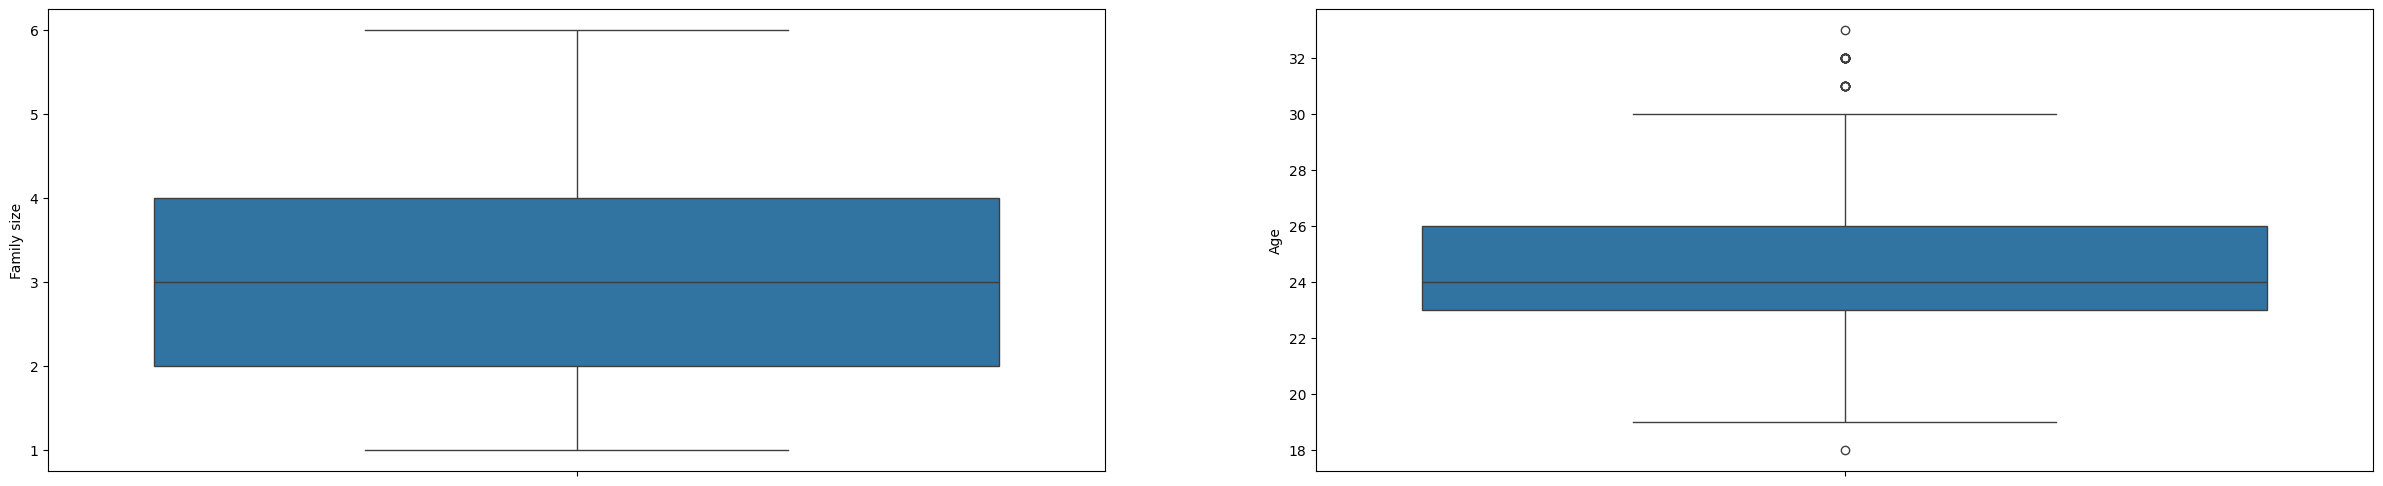

In [16]:
plt.figure( figsize = (30,6) )
plt.subplot(1,2,1)
sns.boxplot( df["Family size"] )
plt.subplot(1,2,2)
sns.boxplot( df["Age"] )

In [17]:
family_size_mean_value = int(df["Family size"].mean())

In [18]:
df["Family size"]= df["Family size"].fillna(family_size_mean_value)

2 ways to fix the outliers

trimming technique - completely remove the outliers

Capping - the outliers above upper limit are replaced by upper limit and values below lower limit are replaced by lower limit

In [19]:
df.describe()

,latitude,Family size,Pin code,Age,longitude
count,388.000000,388.000000,388.000000,369.000000,388.000000
mean,12.972058,3.283505,560040.113402,24.666667,77.600160
std,0.044489,1.322450,31.399609,2.968128,0.051354
min,12.865200,1.000000,560001.000000,18.000000,77.484200
25%,12.936900,2.000000,560010.750000,23.000000,77.565275
50%,12.977000,3.000000,560033.500000,24.000000,77.592100
75%,12.997025,4.000000,560068.000000,26.000000,77.630900
max,13.102000,6.000000,560109.000000,33.000000,77.758200


Need to find out upper limit(Q3+1.5 * IQR) and lower limit(Q1-1.5 * IQR)
#IQR=Q3-Q1
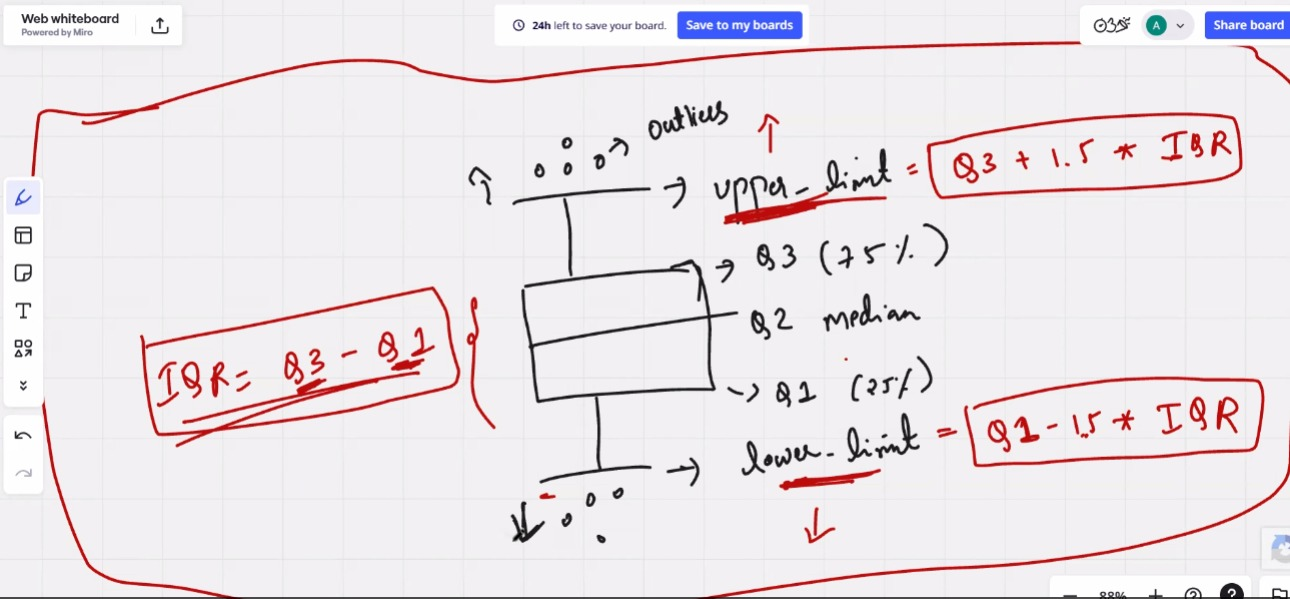

In [20]:
q1 = df.describe()["Age"]["25%"]
q1

np.float64(23.0)

In [21]:
q3 = df.describe()["Age"]["75%"]
q3

np.float64(26.0)

In [22]:
IQR = q3 - q1
IQR

np.float64(3.0)

In [23]:
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print( upper_limit,lower_limit )

30.5 18.5


In [24]:
outliers = df[ (df["Age"]  < lower_limit )  | (df["Age"] >  upper_limit)  ]

In [25]:
non_outliers = df[  ( df["Age"]  >= lower_limit  ) &  ( df["Age"]  <= upper_limit  )  ]

In [ ]:
# trimming

# df = non_outliers

In [26]:
# capping method
df["Age"] = df["Age"].clip( lower_limit , upper_limit )

In [27]:
age_median_val = df["Age"].median()
age_median_val

24.0

In [28]:
df["Age"] = df["Age"].fillna(age_median_val)